# Análise exploratória da arrecadação de IPVA no estado do Rio de Janeiro

Este notebook tem como objetivo explorar os dados de arrecadação de IPVA por município e região administrativa do estado do Rio de Janeiro.

Os dados utilizados foram previamente tratados no notebook de preparação de dados.

O objetivo desta etapa é identificar padrões de arrecadação, diferenças regionais e possíveis concentrações de receita ao longo do ano.

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
# paleta de cores
sns.set_palette('viridis')


In [147]:
df = pd.read_csv('../data/dataset_final/ipva_rj_2017_tratado.csv')

df.head()

,Regiao_Municipio,Janeiro,Fevereiro,Marco,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro
0,BAIXADAS LITORANEAS,46327190.67,29338614.97,23906407.38,13944494.19,7111693.59,5765980.59,5282980.99,4861707.96,3631253.29,2881701.40,1937152.92
1,ARARUAMA,5499064.37,3587746.70,3070719.76,1870401.42,951973.15,724117.04,692563.70,665014.90,483490.27,390837.50,251095.72
2,ARMACAO DE BUZIOS,2899656.20,1968671.63,1377890.22,822523.50,370058.23,304156.87,264208.89,276428.04,238889.24,215926.30,151302.58
3,ARRAIAL DO CABO,1389101.25,831078.30,695238.83,396987.24,216519.39,152048.40,150634.02,128394.08,90167.27,82533.68,53348.60
4,CABO FRIO,11595135.85,7492964.60,6219131.72,3581646.30,1754444.91,1419880.92,1294806.43,1196768.31,897946.49,722503.99,508129.32


* Qual mês apresenta maior arrecadação de IPVA ao longo do ano?

Nesta etapa buscamos identificar quais meses concentram a maior arrecadação de IPVA no estado do Rio de Janeiro.  
Para isso, será calculada a soma da arrecadação de todos os municípios para cada mês do ano.

In [148]:
meses = [
'Janeiro', 'Fevereiro', 'Marco', 'Maio',
'Junho', 'Julho', 'Agosto', 'Setembro',
'Outubro', 'Novembro', 'Dezembro'
]

In [149]:
arrecadacao_mensal = df[meses].sum()

arrecadacao_mensal

Janeiro      1.453937e+09
Fevereiro    8.791773e+08
Marco        6.322748e+08
Maio         3.724043e+08
Junho        1.852322e+08
Julho        1.522372e+08
Agosto       1.346758e+08
Setembro     1.257809e+08
Outubro      9.496665e+07
Novembro     7.290152e+07
Dezembro     5.224653e+07
dtype: float64

In [150]:
arrecadacao_mensal.idxmax()

'Janeiro'

C:\Users\samue\AppData\Local\Temp\ipykernel_4348\2952266128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


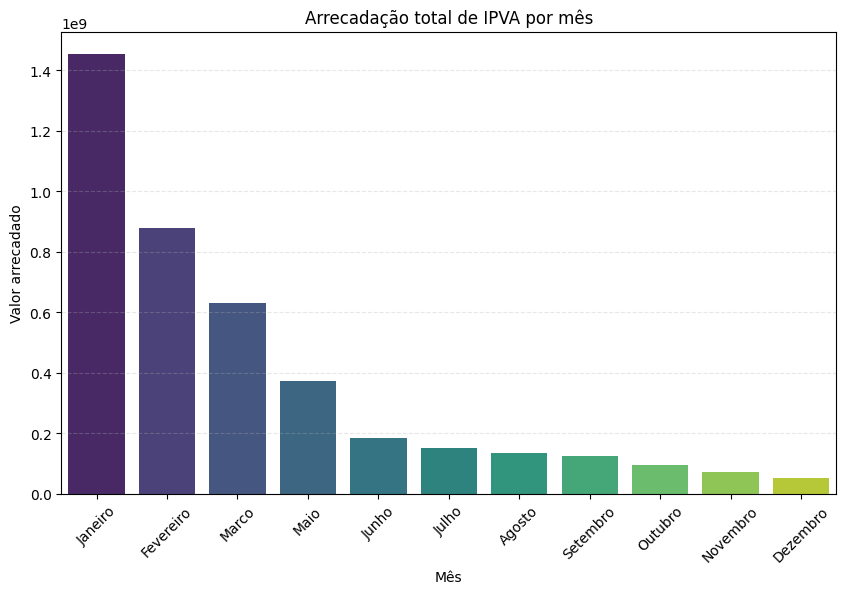

In [165]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=arrecadacao_mensal.index,
    y=arrecadacao_mensal.values,
    palette="viridis"
)

plt.title("Arrecadação total de IPVA por mês")
plt.ylabel("Valor arrecadado")
plt.xlabel("Mês")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

### Observação

Observa-se que a arrecadação de IPVA apresenta forte concentração nos primeiros meses do ano, com destaque para o mês de janeiro.

Esse comportamento ocorre devido ao calendário de pagamento do imposto, que normalmente possui vencimentos concentrados no início do ano, quando grande parte dos contribuintes realiza o pagamento integral ou das primeiras parcelas.

---
* Concentração de arrecadação por município e região

Nesta etapa analisamos a distribuição da arrecadação anual de IPVA sob duas perspectivas:

Municípios com maior arrecadação anual
Regiões administrativas com maior arrecadação

O objetivo é identificar onde se concentram os maiores volumes de arrecadação no estado do Rio de Janeiro.

In [152]:
meses = [
'Janeiro','Fevereiro','Marco','Maio',
'Junho','Julho','Agosto','Setembro',
'Outubro','Novembro','Dezembro'
]

df['Arrecadacao_Anual'] = df[meses].sum(axis=1)

In [153]:
regioes = [
'METROPOLITANA',
'SERRANA',
'NORTE',
'NOROESTE',
'BAIXADAS LITORANEAS',
'MEDIO PARAIBA',
'CENTRO-SUL',
'COSTA VERDE'
]

C:\Users\samue\AppData\Local\Temp\ipykernel_4348\4224648898.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\samue\AppData\Local\Temp\ipykernel_4348\4224648898.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


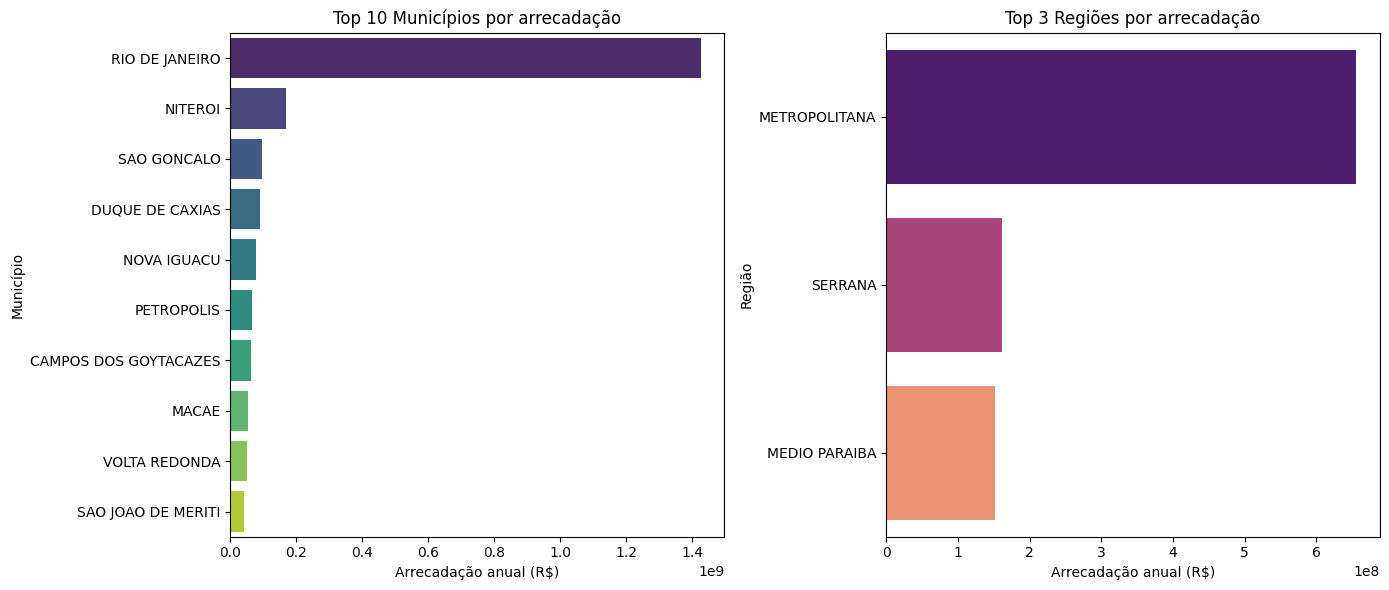

In [154]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

# municípios
sns.barplot(
    data=top_municipios,
    x='Arrecadacao_Anual',
    y='Regiao_Municipio',
    palette='viridis',
    ax=axes[0]
)

axes[0].set_title("Top 10 Municípios por arrecadação")
axes[0].set_xlabel("Arrecadação anual (R$)")
axes[0].set_ylabel("Município")


# regiões
sns.barplot(
    data=top_regioes,
    x='Arrecadacao_Anual',
    y='Regiao_Municipio',
    palette='magma',
    ax=axes[1]
)

axes[1].set_title("Top 3 Regiões por arrecadação")
axes[1].set_xlabel("Arrecadação anual (R$)")
axes[1].set_ylabel("Região")

plt.tight_layout()

plt.show()

In [155]:
df['Participacao_%'] = (
    df['Arrecadacao_Anual'] /
    df['Arrecadacao_Anual'].sum()
) * 100
print(f"Participação percentual do município com maior arrecadação: {df['Participacao_%'].max():.2f}%")

Participação percentual do município com maior arrecadação: 34.32%


### Observações

A análise evidencia uma forte concentração da arrecadação de IPVA em poucos municípios do estado.

O município do **Rio de Janeiro** apresenta destaque significativo, concentrando **34,32% de toda a arrecadação anual** observada no conjunto de dados. Esse resultado indica que mais de um terço da arrecadação estadual do imposto está associado à capital.

Esse padrão pode ser explicado por fatores estruturais como a maior população do estado, elevada concentração de veículos registrados e maior atividade econômica.

Outros municípios da região metropolitana também aparecem entre os maiores arrecadadores, reforçando a tendência de que a arrecadação do imposto acompanha a densidade populacional, o nível de urbanização e o tamanho da frota de veículos.


----
* Como a arrecadação se comporta ao longo dos meses do ano?



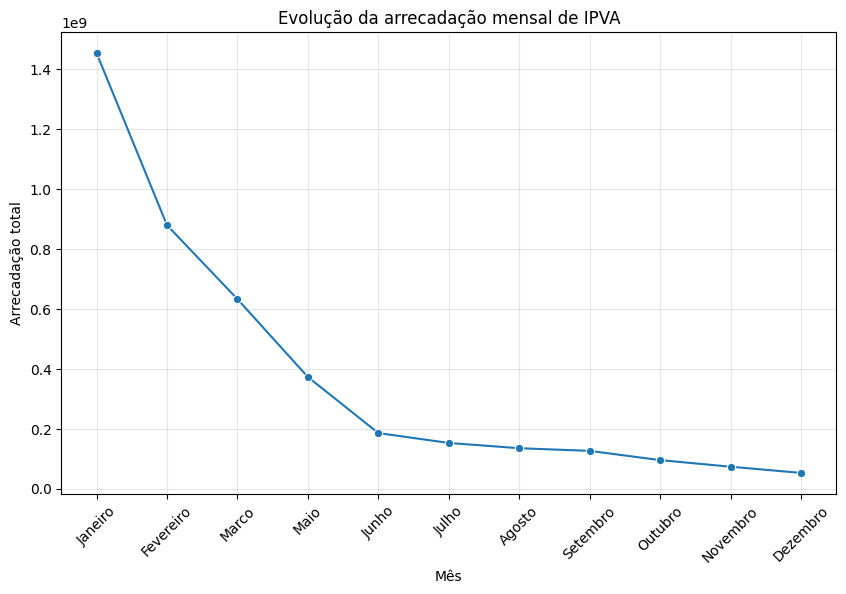

In [156]:
arrecadacao_mensal = df[meses].sum()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=arrecadacao_mensal.index,
    y=arrecadacao_mensal.values,
    marker='o'
)

plt.title("Evolução da arrecadação mensal de IPVA")
plt.xlabel("Mês")
plt.ylabel("Arrecadação total")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Observações

A arrecadação de IPVA apresenta forte concentração nos primeiros meses do ano, com destaque para o mês de janeiro.

Esse comportamento está diretamente relacionado ao calendário de pagamento do imposto, que normalmente concentra o pagamento à vista ou das primeiras parcelas no início do ano.

Após esse período inicial, observa-se uma redução gradual no volume arrecadado ao longo dos meses seguintes.

In [157]:
regioes = [
'METROPOLITANA',
'SERRANA',
'NORTE',
'NOROESTE',
'BAIXADAS LITORANEAS',
'MEDIO PARAIBA',
'CENTRO-SUL',
'COSTA VERDE'
]

df_regioes = df[df['Regiao_Municipio'].isin(regioes)]
df_municipios = df[~df['Regiao_Municipio'].isin(regioes)]

In [158]:
top_municipios = df_municipios.sort_values(
    'Arrecadacao_Anual',
    ascending=False
).head(5)

top_municipios = df_municipios.sort_values(
    'Arrecadacao_Anual',
    ascending=False
).head(10)

In [159]:
dados_heatmap = top_municipios.set_index(
    'Regiao_Municipio'
)[meses]

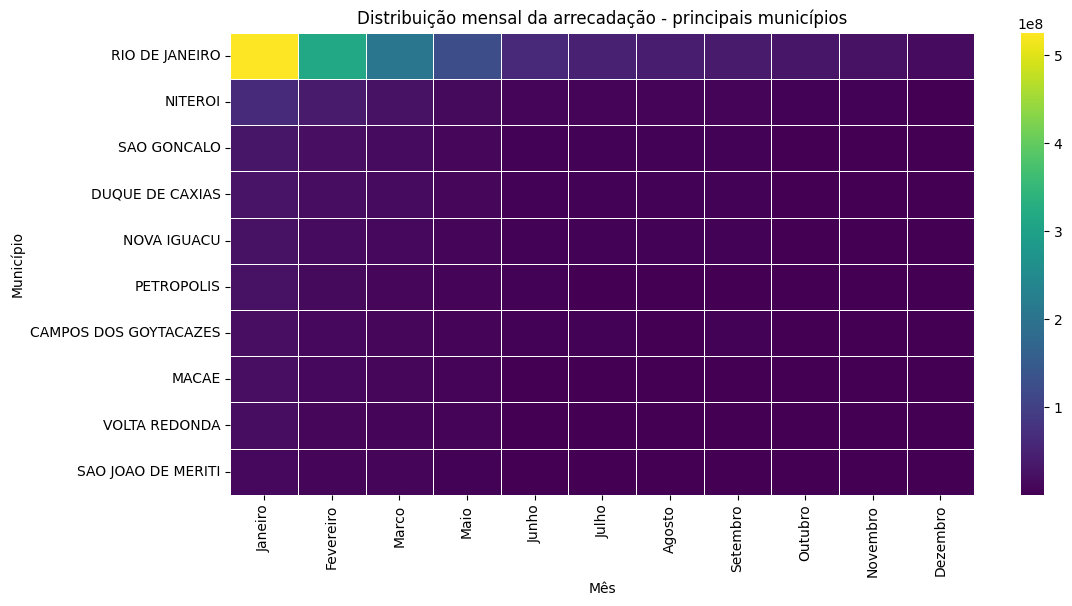

In [160]:
plt.figure(figsize=(12,6))

sns.heatmap(
    dados_heatmap,
    cmap='viridis',
    linewidths=0.5
)

plt.title("Distribuição mensal da arrecadação - principais municípios")
plt.xlabel("Mês")
plt.ylabel("Município")

plt.show()

### Observações

A análise da distribuição mensal da arrecadação entre os principais municípios mostra um padrão semelhante entre todas as cidades analisadas.

Observa-se maior intensidade de arrecadação nos primeiros meses do ano, especialmente em janeiro e fevereiro, com redução gradual nos meses subsequentes.

Esse comportamento reforça o padrão sazonal do IPVA, cuja arrecadação tende a se concentrar no início do calendário fiscal.

---
* Quanto da arrecadação anual acontece nos 3 primeiros meses?

In [167]:
primeiros_meses = arrecadacao_mensal[['Janeiro','Fevereiro','Marco']].sum()

total = arrecadacao_mensal.sum()

percentual = (primeiros_meses / total) * 100

percentual

print(f"Percentual arrecadado nos 3 primeiros meses: {percentual:.2f}%")

Percentual arrecadado nos 3 primeiros meses: 71.35%


A análise indica que aproximadamente 71.35% da arrecadação anual de IPVA ocorre nos três primeiros meses do ano, evidenciando forte concentração da arrecadação no início do calendário fiscal.

## Síntese da Análise Exploratória

Nesta etapa foi realizada a **análise exploratória dos dados de arrecadação de IPVA no estado do Rio de Janeiro**, com o objetivo de compreender padrões gerais de distribuição da arrecadação entre meses, municípios e regiões administrativas.

Entre os principais pontos observados ao longo da análise, destacam-se:

* **Forte concentração da arrecadação nos primeiros meses do ano**, especialmente em janeiro, refletindo o calendário de pagamento do imposto.
* **Alta concentração geográfica da arrecadação**, com destaque para o município do Rio de Janeiro, responsável por aproximadamente **34,32% da arrecadação total** observada no conjunto de dados.
* Predominância de **municípios da região metropolitana entre os maiores arrecadadores**, indicando relação direta entre arrecadação, densidade populacional e tamanho da frota de veículos.
* Padrões semelhantes de distribuição mensal entre os principais municípios analisados, reforçando a **sazonalidade característica do imposto**.

De forma geral, a análise exploratória permitiu identificar **padrões estruturais relevantes da arrecadação**, além de validar a consistência dos dados preparados na etapa anterior de tratamento.

## Próxima etapa

Com base nos resultados obtidos nesta exploração inicial, será elaborado um **relatório analítico consolidado**, contendo visualizações selecionadas e interpretações dos principais indicadores de arrecadação.

Esse relatório terá como objetivo **apresentar os principais insights da análise de forma mais sintética e interpretativa**, facilitando a compreensão dos padrões de arrecadação do IPVA no estado do Rio de Janeiro.
